In [1]:
import pandas as pd
import numpy as np
from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator
from ta.volatility import AverageTrueRange
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# ==========================
# Load data
# ==========================
df = pd.read_csv("newm_data.csv")
df

,Price
0,72.90
1,72.90
2,72.90
3,72.75
4,72.75
...,...
22724,35.90
22725,35.90
22726,35.90
22727,35.95


In [3]:
df.isna().sum()

Price    0
dtype: int64

In [4]:
df["Price"] = df["Price"].astype(float)

In [5]:
# Parameters
qty = 5000
brokerage_pct = 0.0012  # 0.12% per side
atr_multiplier_sl = 1.5  # SL = ATR * 1.5
atr_multiplier_tp = 2    # TP = ATR * 2
ml_threshold = 0.55      # ML probability threshold to allow trades
cooldown= 4                                                                      

In [6]:
# Indicators
# ==========================
df["RSI"] = RSIIndicator(df["Price"], window=14).rsi()
df["SMA_fast"] = SMAIndicator(df["Price"], window=20).sma_indicator()
df["SMA_slow"] = SMAIndicator(df["Price"], window=50).sma_indicator()
df["ATR"] = AverageTrueRange(df["Price"], df["Price"], df["Price"], window=14).average_true_range()

In [7]:
# Signals
# ==========================
df["buy_signal"] = (df["SMA_fast"] > df["SMA_slow"]) & (df["RSI"] < 65)
df["sell_signal"] = (df["SMA_fast"] < df["SMA_slow"]) | (df["RSI"] > 70)

In [9]:
# Prepare ML Data
# ==========================
df["Forward_Return"] = df["Price"].shift(-1) - df["Price"]
df["Target"] = (df["Forward_Return"] > 0).astype(int)

features = ["RSI", "SMA_fast", "SMA_slow", "ATR"]
df = df.dropna().reset_index(drop=True)
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
X = df[features]
y = df["Target"]

# Train-test split (no shuffle = preserve time order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# ML prediction probability
df["ML_Prob"] = clf.predict_proba(X)[:, 1]


====== ML Model Performance ======
Accuracy: 0.7209

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83      3450
           1       0.25      0.09      0.13      1086

    accuracy                           0.72      4536
   macro avg       0.51      0.50      0.48      4536
weighted avg       0.64      0.72      0.66      4536



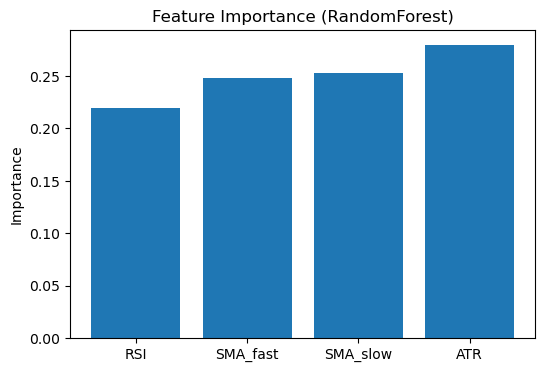

In [10]:
# Evaluate ML model
# ==========================
y_pred = clf.predict(X_test)
print("\n====== ML Model Performance ======")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance plot
importances = clf.feature_importances_
plt.figure(figsize=(6,4))
plt.bar(features, importances)
plt.title("Feature Importance (RandomForest)")
plt.ylabel("Importance")
plt.show()

In [11]:
# Backtest with ATR SL/TP + ML filter
# ==========================
def backtest_atr_sl_tp(prices, buy_signal, sell_signal, atr, qty, brokerage_pct, atr_sl, atr_tp, ml_probs, ml_threshold, cooldown=4):
    entry_indices, exit_indices = [], []
    entry_prices, exit_prices = [], []
    profits, cum_profits, capital_history = [], [], []

    in_trade = False
    cum_profit = 0
    capital = prices[0] * qty  # starting capital
    last_exit_index = -cooldown  # ensure we can enter first trade

    for i in range(len(prices)-1):
        # Entry condition (buy_signal just turned true + cooldown gap + ML filter)
        if buy_signal[i] and not buy_signal[i-1] and not in_trade and (i - last_exit_index) >= cooldown:
            if ml_probs[i] >= ml_threshold:  # <-- ML filter
                entry_index = i + 1
                entry_price = prices[entry_index]
                sl_price = entry_price - atr[i] * atr_sl
                tp_price = entry_price + atr[i] * atr_tp
                in_trade = True
            continue

        if in_trade:
            exit_index = i + 1
            current_price = prices[exit_index]
            if exit_index-entry_index < 3:
                continue
                
            # Exit conditions: sell signal or SL/TP hit
            if current_price <= sl_price or current_price >= tp_price or (sell_signal[i] and not sell_signal[i-1]):
                exit_price = current_price
                # Profit with brokerage
                raw_profit = (exit_price - entry_price) * qty
                cost = (entry_price + exit_price) * brokerage_pct
                profit = raw_profit - cost

                # Track trades
                entry_indices.append(entry_index)
                exit_indices.append(exit_index)
                entry_prices.append(entry_price)
                exit_prices.append(exit_price)
                profits.append(profit)

                cum_profit += profit
                capital += profit
                cum_profits.append(cum_profit)
                capital_history.append(capital)

                in_trade = False
                last_exit_index = exit_index  # mark last exit

    trade_log = pd.DataFrame({
        "EntryIndex": entry_indices,
        "EntryPrice": entry_prices,
        "ExitIndex": exit_indices,
        "ExitPrice": exit_prices,
        "Profit": profits,
        "CumProfit": cum_profits,
        "CapitalAfterTrade": capital_history
    })

    total_trades = len(trade_log)
    winning_trades = (trade_log["Profit"] > 0).sum()
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    total_profit = trade_log["Profit"].sum()
    avg_profit = trade_log["Profit"].mean() if total_trades > 0 else 0

    performance = {
        "Total Trades": total_trades,
        "Winning Trades": winning_trades,
        "Win Rate": round(win_rate, 2),
        "Total Profit": round(total_profit, 2),
        "Average Profit per Trade": round(avg_profit, 2),
        "Starting Capital": round(prices[0] * qty, 2),
        "Final Capital": round(prices[0] * qty + total_profit, 2)
    }

    return performance, trade_log

In [12]:
# Run Backtest with ML
# ==========================
performance, trade_log = backtest_atr_sl_tp(
    df["Price"].values,
    df["buy_signal"].values,
    df["sell_signal"].values,
    df["ATR"].values,
    qty,
    brokerage_pct,
    atr_multiplier_sl,
    atr_multiplier_tp,
    df["ML_Prob"].values,
    ml_threshold
)



======Strategy Performance ======
Total Trades: 91
Winning Trades: 42
Win Rate: 46.15
Total Profit: 9490.08
Average Profit per Trade: 104.29
Starting Capital: 363500.0
Final Capital: 372990.08

Sample Trade Log:
   EntryIndex  EntryPrice  ExitIndex  ExitPrice      Profit   CumProfit  \
0         511       66.85        514      66.50 -1750.16002 -1750.16002   
1         553       67.05        557      66.80 -1250.16062 -3000.32064   
2         731       67.25        734      67.50  1249.83830 -1750.48234   
3         739       67.50        742      67.70   999.83776  -750.64458   
4         759       68.10        765      68.65  2749.83590  1999.19132   
5         880       69.00        883      69.40  1999.83392  3999.02524   
6        1114       68.50       1117      68.10 -2000.16392  1998.86132   
7        1136       67.80       1139      67.20 -3000.16200 -1001.30068   
8        1347       57.15       1353      58.25  5499.86152  4498.56084   
9        1547       59.30       1552 

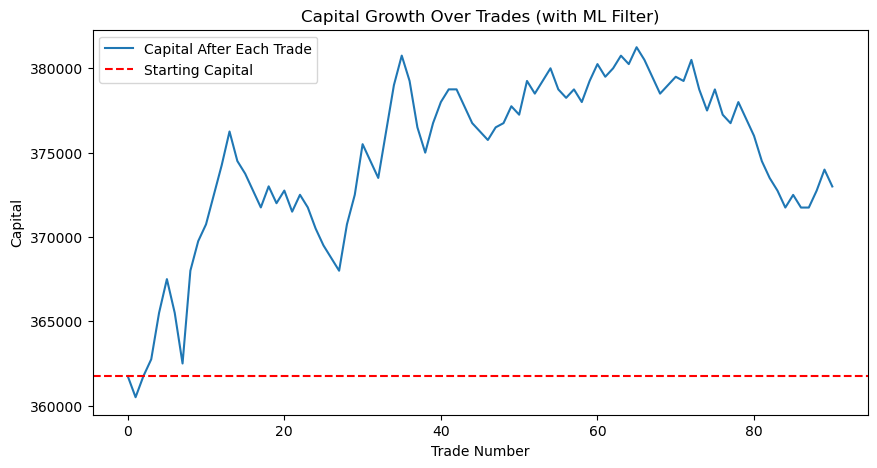

In [13]:
# Results
# ==========================
print("\n======Strategy Performance ======")
for k, v in performance.items():
    print(f"{k}: {v}")

print("\nSample Trade Log:")
print(trade_log.head(10))

# ==========================
# Plot Capital Curve
# ==========================
plt.figure(figsize=(10,5))
plt.plot(trade_log["CapitalAfterTrade"], label="Capital After Each Trade")
plt.axhline(trade_log["CapitalAfterTrade"].iloc[0], color="red", linestyle="--", label="Starting Capital")
plt.legend()
plt.xlabel("Trade Number")
plt.ylabel("Capital")
plt.title("Capital Growth Over Trades (with ML Filter)")
plt.show()

In [14]:
df

,Price,RSI,SMA_fast,SMA_slow,ATR,buy_signal,sell_signal,Forward_Return,Target,ML_Prob
0,72.70,54.152878,72.5050,72.634,0.099080,False,True,0.00,0,0.11
1,72.70,54.152878,72.5000,72.630,0.092003,False,True,0.00,0,0.16
2,72.70,54.152878,72.4950,72.626,0.085431,False,True,0.20,1,0.73
3,72.90,61.219216,72.4950,72.626,0.093615,False,True,0.00,0,0.14
4,72.90,61.219216,72.4950,72.629,0.086928,False,True,0.35,1,0.69
...,...,...,...,...,...,...,...,...,...,...
22674,36.20,40.752065,36.3475,36.382,0.060270,False,True,-0.30,0,0.16
22675,35.90,29.468777,36.3400,36.367,0.077394,False,True,0.00,0,0.24
22676,35.90,29.468777,36.3450,36.352,0.071866,False,True,0.00,0,0.16
22677,35.90,29.468777,36.3500,36.337,0.066733,True,False,0.05,1,0.23


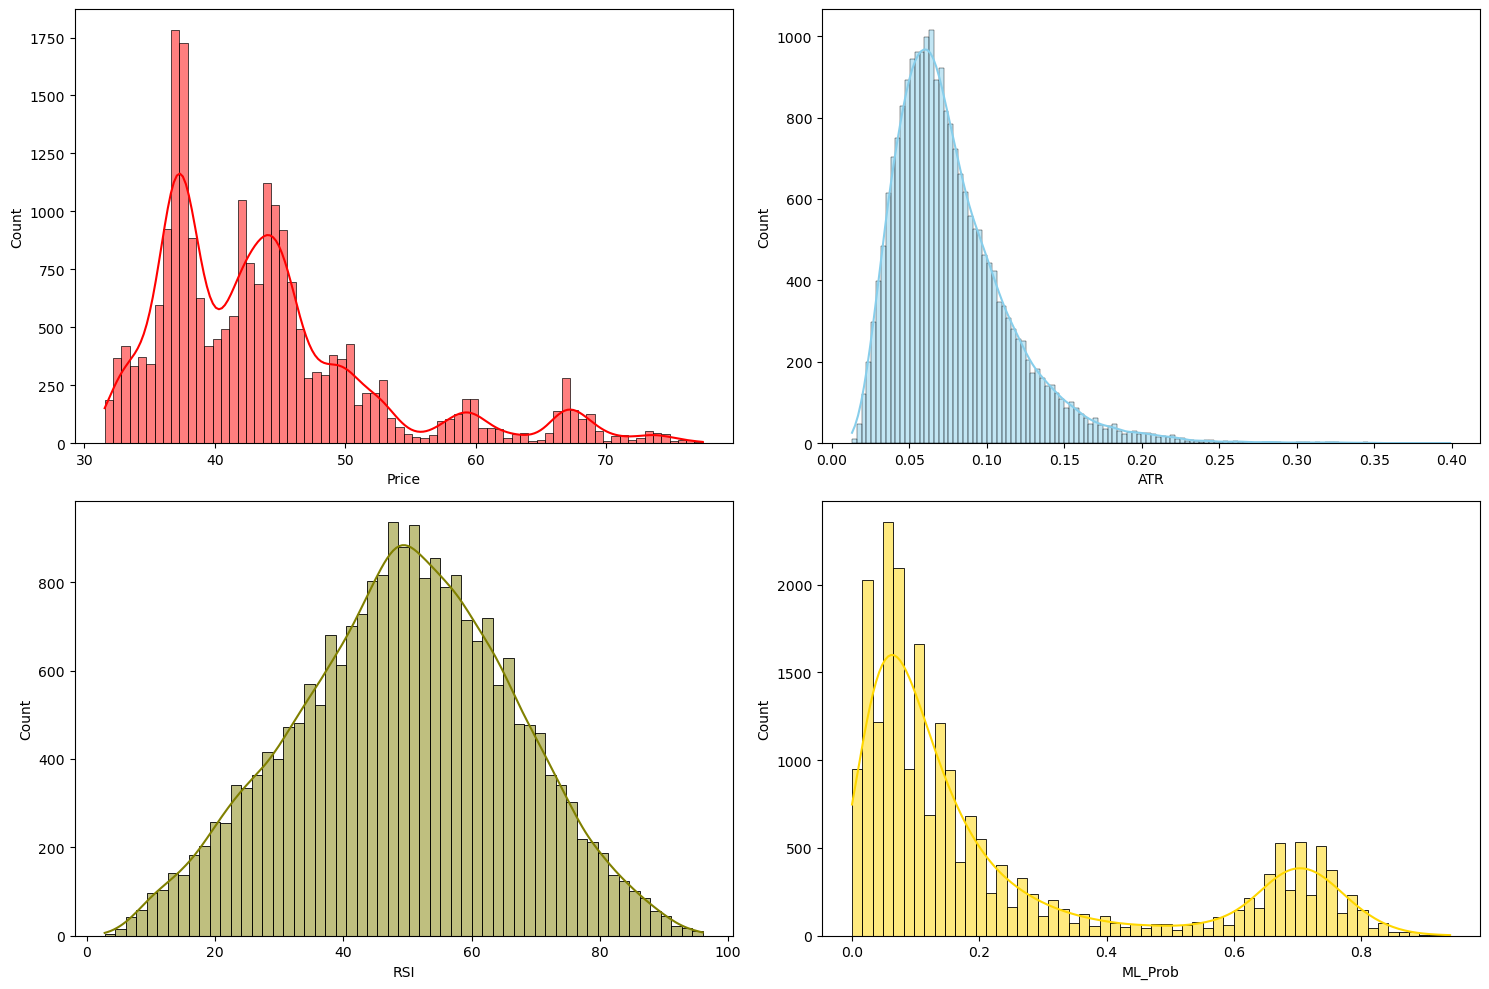

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df, x="Price", kde=True, color="red", ax=axs[0, 0])
sns.histplot(data=df, x="ATR", kde=True, color="skyblue", ax=axs[0, 1])
sns.histplot(data=df, x="RSI", kde=True, color="olive", ax=axs[1, 0])
sns.histplot(data=df, x="ML_Prob", kde=True, color="gold", ax=axs[1, 1])

plt.tight_layout()
plt.show()

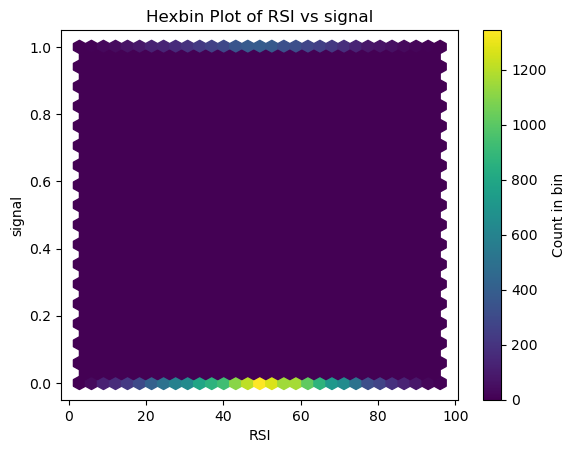

In [16]:
import matplotlib.pyplot as plt

# Example data
x = df['RSI']       # Example variable 1
y = df['Target']       # Example variable 2

plt.hexbin(x, y, gridsize=30, cmap='viridis')
plt.colorbar(label='Count in bin')
plt.xlabel('RSI')
plt.ylabel('signal')
plt.title('Hexbin Plot of RSI vs signal')
plt.show()


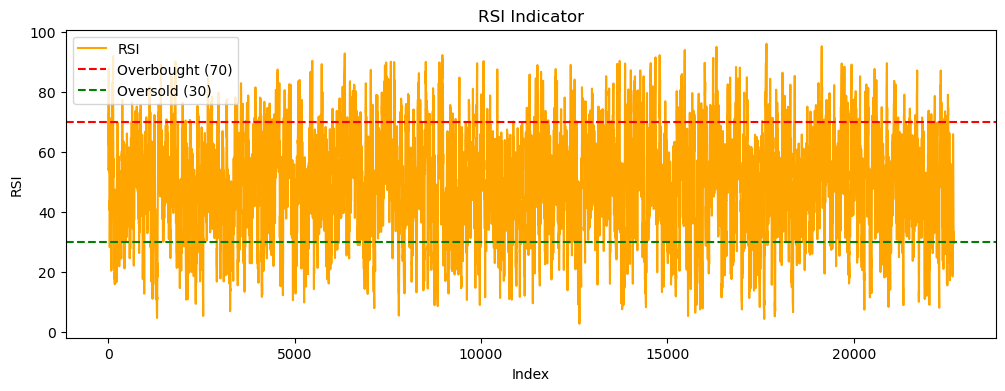

In [17]:
#RSI with Overbought/Oversold Levels
plt.figure(figsize=(12,4))
plt.plot(df["RSI"], label="RSI", color="orange")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.legend()
plt.title("RSI Indicator")
plt.xlabel("Index")
plt.ylabel("RSI")
plt.show()


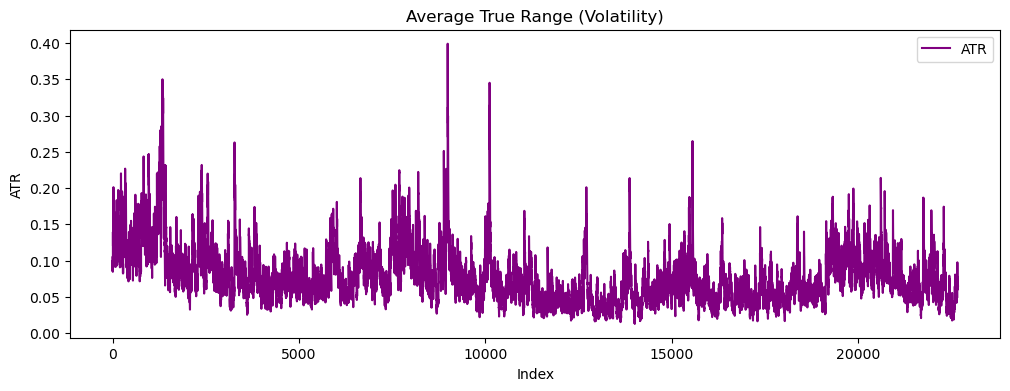

In [18]:
#ATR (Volatility) over Time
plt.figure(figsize=(12,4))
plt.plot(df["ATR"], label="ATR", color="purple")
plt.legend()
plt.title("Average True Range (Volatility)")
plt.xlabel("Index")
plt.ylabel("ATR")
plt.show()


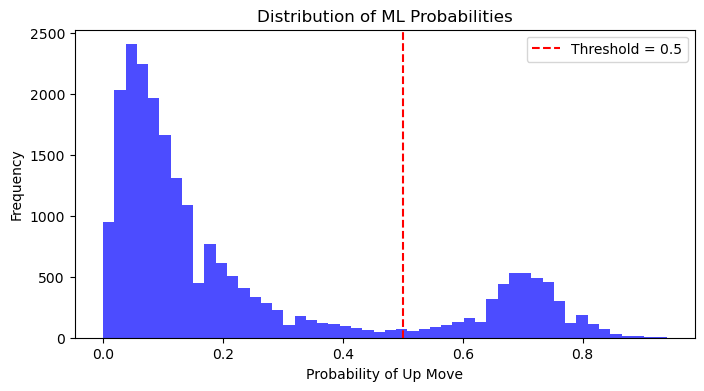

In [20]:
#ML Probability Histogram
plt.figure(figsize=(8,4))
plt.hist(df["ML_Prob"], bins=50, color="blue", alpha=0.7)
plt.axvline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
plt.legend()
plt.title("Distribution of ML Probabilities")
plt.xlabel("Probability of Up Move")
plt.ylabel("Frequency")
plt.show()


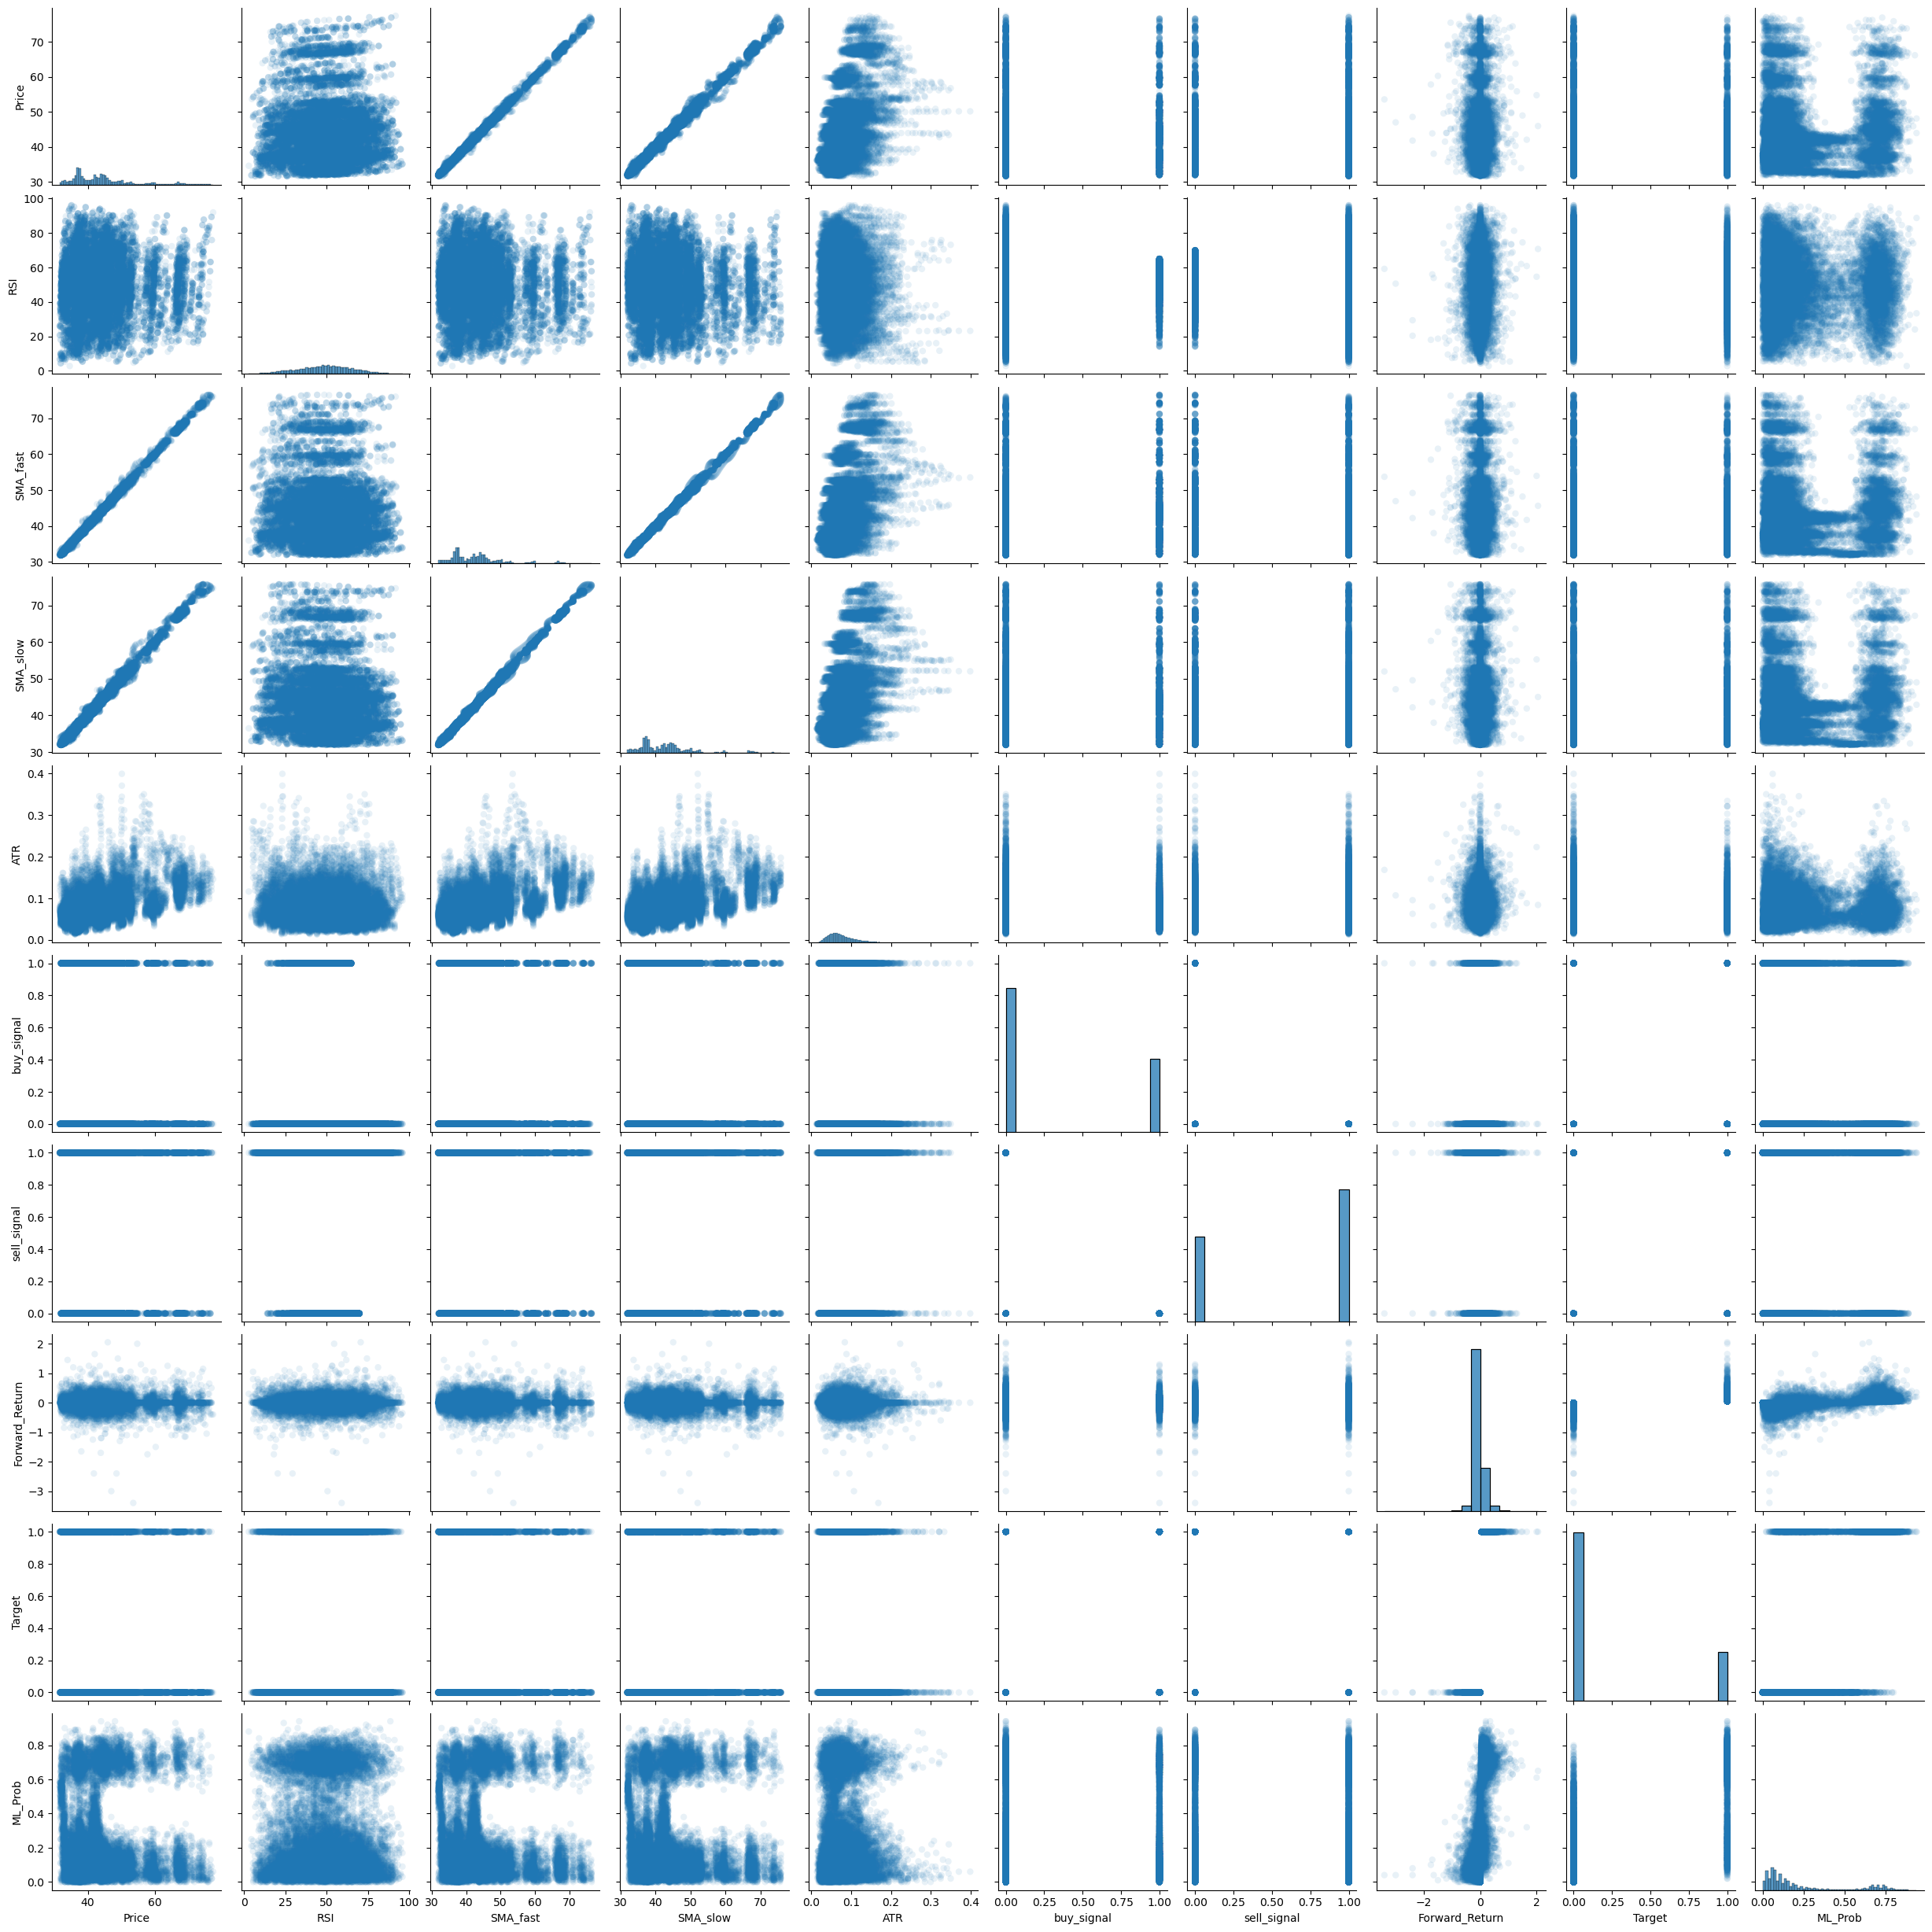

In [21]:
sns.pairplot(df, plot_kws=dict(alpha=.1, edgecolor='none'))

In [22]:
df.describe()

,Price,RSI,SMA_fast,SMA_slow,ATR,Forward_Return,Target,ML_Prob
count,22679.000000,22679.000000,22679.000000,22679.000000,22679.000000,22679.000000,22679.000000,22679.000000
mean,43.777625,49.384923,43.792837,43.816890,0.077701,-0.001620,0.224525,0.229077
std,8.664307,16.994584,8.677741,8.698991,0.037894,0.162514,0.417278,0.246846
min,31.550000,2.763676,31.792500,31.913000,0.013059,-3.400000,0.000000,0.000000
25%,37.400000,37.828839,37.453750,37.430000,0.051509,0.000000,0.000000,0.060000
50%,42.250000,49.790458,42.247500,42.268000,0.069763,0.000000,0.000000,0.120000
75%,46.450000,61.385977,46.455000,46.527500,0.095571,0.000000,0.000000,0.290000
max,77.400000,96.041682,76.570000,75.790000,0.398993,2.050000,1.000000,0.940000


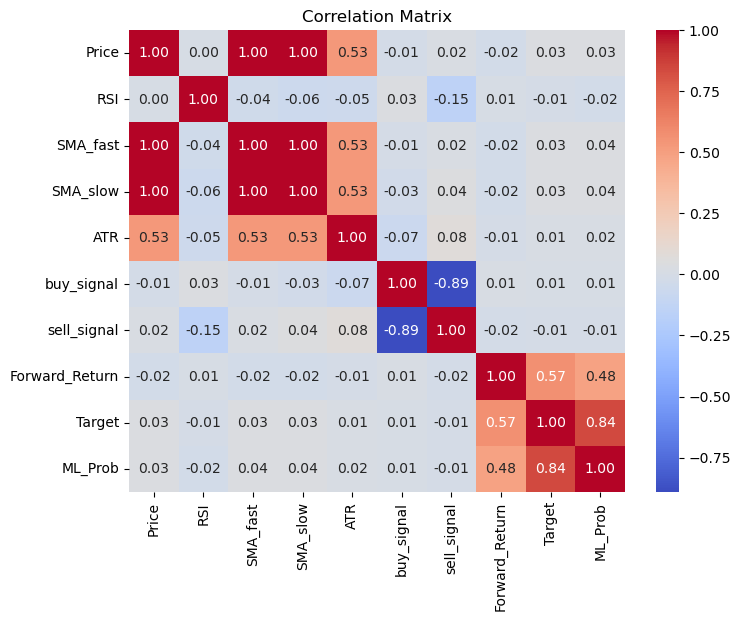

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [24]:
df.corr()

,Price,RSI,SMA_fast,SMA_slow,ATR,buy_signal,sell_signal,Forward_Return,Target,ML_Prob
Price,1.000000,0.004921,0.998885,0.996974,0.527653,-0.011911,0.019036,-0.021518,0.033685,0.034184
RSI,0.004921,1.000000,-0.035138,-0.060208,-0.050221,0.034899,-0.149015,0.005576,-0.007879,-0.021091
SMA_fast,0.998885,-0.035138,1.000000,0.998866,0.530536,-0.007527,0.018432,-0.021915,0.033863,0.035118
SMA_slow,0.996974,-0.060208,0.998866,1.000000,0.533187,-0.028638,0.043267,-0.022118,0.033796,0.035029
ATR,0.527653,-0.050221,0.530536,0.533187,1.000000,-0.068102,0.076325,-0.005150,0.013342,0.015406
buy_signal,-0.011911,0.034899,-0.007527,-0.028638,-0.068102,1.000000,-0.890734,0.012017,0.009156,0.008296
sell_signal,0.019036,-0.149015,0.018432,0.043267,0.076325,-0.890734,1.000000,-0.016129,-0.010529,-0.005922
Forward_Return,-0.021518,0.005576,-0.021915,-0.022118,-0.005150,0.012017,-0.016129,1.000000,0.566172,0.484892
Target,0.033685,-0.007879,0.033863,0.033796,0.013342,0.009156,-0.010529,0.566172,1.000000,0.841195
ML_Prob,0.034184,-0.021091,0.035118,0.035029,0.015406,0.008296,-0.005922,0.484892,0.841195,1.000000


In [25]:
pip install streamlit_jupyter

   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   -------- ------------------------------- 30.7/139.8 kB 1.3 MB/s eta 0:00:01
   -------- ------------------------------- 30.7/139.8 kB 1.3 MB/s eta 0:00:01
   ----------- --------------------------- 41.0/139.8 kB 326.8 kB/s eta 0:00:01
   ------------------- ------------------- 71.7/139.8 kB 391.3 kB/s eta 0:00:01
   ------------------------------ ------- 112.6/139.8 kB 502.0 kB/s eta 0:00:01
   --------------------------------- ---- 122.9/139.8 kB 479.3 kB/s eta 0:00:01
   --------------------------------- ---- 122.9/139.8 kB 479.3 kB/s eta 0:00:01
   -------------------------------------- 139.8/139.8 kB 376.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/79.4 kB ? eta -:--:--
   --------------- ------------------------ 30.7/79.4 kB 660.6 kB/s eta 0:00:01
   ------------------------------ --------- 61.4/79.4 kB 825.8 kB/s eta 0:00:01
   ---------------------------------------- 79.4/79.4 kB 744.